In [73]:
#Aufgabe 3_1
import pandas as pd

# Load the training data
X_train = pd.read_csv("../Daten//X_train.csv", index_col=0) 
y_train = pd.read_csv("../Daten//y_train.csv", index_col=0) 

# 1. Report observations and variables
n_obs, n_variables = X_train.shape
print(f"Observations: {n_obs}, Variables: {n_variables}")

# 2. Fraction of borrowers who defaulted
default_fraction = y_train.mean().values[0]
print(f"Fraction of defaults: {default_fraction:.2%}")

# 3. Summary statistics
summary_stats = X_train.describe().loc[['mean', 'std', 'min', 'max']]
print(summary_stats)


analysis = f"""
Features must be scaled before using distance-based methods like KNN or SVM. These algorithms rely on Euclidean distance.
without scaling, variables with large numerical ranges (like income) would dominate the distance calculation, making smaller-scale features 
mathematically invisible regardless of their actual predictive power."""

print(analysis)

Observations: 5000, Variables: 20
Fraction of defaults: 35.02%
      annual_income        age  employment_years  debt_to_income  \
mean   50309.452058  43.626200          5.733020        0.166050   
std    29349.199007  12.364216          4.166518        0.159139   
min     5473.630000  22.000000          0.100000        0.007300   
max   338861.400000  65.000000         40.000000        1.500000   

      credit_score  credit_utilization  num_open_accounts  \
mean    678.794200            0.280992           4.948400   
std      75.449405            0.156996           2.193422   
min     434.000000            0.006200           0.000000   
max     850.000000            0.869900          13.000000   

      num_credit_inquiries   loan_amount  interest_rate  loan_term_months  \
mean              2.473600  11827.435264       8.402370         37.152000   
std               1.568373   6533.911480       2.097997         14.089961   
min               0.000000   1812.350000       2.000000    

In [74]:
#Aufgabe 3_2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 

# 2. Fit Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train.values.ravel())

# 3. Report training accuracy
y_pred = log_reg.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy: {train_accuracy:.4f}") # 

# 4. Analyze coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': abs(log_reg.coef_[0])
}).sort_values(by='Abs_Coefficient', ascending=False)

print("Top 3 features by absolute coefficient:")
print(coef_df.head(3)) 

# %%
text = f"""
Standardizing features (mean 0, std 1) is essential for comparing coefficients. It ensures that the magnitude of each 
coefficient represents the change in log-odds for a one-standard-deviation increase in the feature, putting all predictors 
on an equal playing field.

debt_to_income: This feature has the strongest positive association with risk; higher debt relative to income significantly increases the likelihood of default.

credit_utiization: This feature has a moderate positive association; while it contributes to risk, its impact is less pronounced than the top three features, suggesting it may be a secondary factor in predicting defaults.

previous_defaults: Indicates a strong positive association with risk; prior defaults are often the best predictor of future ones."""
print(text)

Training Accuracy: 0.7298
Top 3 features by absolute coefficient:
               Feature  Coefficient  Abs_Coefficient
3       debt_to_income     0.853965         0.853965
5   credit_utilization     0.378353         0.378353
18   previous_defaults     0.368845         0.368845

Standardizing features (mean 0, std 1) is essential for comparing coefficients. It ensures that the magnitude of each 
coefficient represents the change in log-odds for a one-standard-deviation increase in the feature, putting all predictors 
on an equal playing field.

debt_to_income: This feature has the strongest positive association with risk; higher debt relative to income significantly increases the likelihood of default.

credit_utiization: This feature has a moderate positive association; while it contributes to risk, its impact is less pronounced than the top three features, suggesting it may be a secondary factor in predicting defaults.

previous_defaults: Indicates a strong positive association with r

In [75]:
# Aufgabe 3_3
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd


# 1. Split the data into training and validation sets
X_train_k, X_val_k, y_train_k, y_val_k = train_test_split(
    X_train_scaled, y_train.values.ravel(), test_size=0.2, random_state=12883823
)

# 2. Define parameters to test: k ∈ {5, 20, 50} and weights
k_values = [5, 20, 50]
weight_options = ['uniform', 'distance']

results = []

# 3. Iterative testing 
for k in k_values:
    for weight in weight_options:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weight)
        knn.fit(X_train_k, y_train_k)
        
        # Calculate error rate (1 - accuracy) [cite: 157]
        accuracy = knn.score(X_val_k, y_val_k)
        error_rate = 1 - accuracy
        
        results.append({
            'k': k,
            'weights': weight,
            'error_rate': error_rate
        })

# 4. Display results
knn_results_df = pd.DataFrame(results)
print(knn_results_df)


analysis = f"""
standardized features work best because KNN identifies neighbors based on distance, and large-scale variables would otherwise drown 
out smaller, more predictive ones. KNN struggles with this dataset because raw features like income or debt have vastly different ranges, 
causing the algorithm to incorrectly prioritize high-magnitude numbers over actual risk factors. Standardization levels the playing field, 
ensuring every feature contributes equally to the distance calculation."""
print(analysis)

    k   weights  error_rate
0   5   uniform       0.311
1   5  distance       0.311
2  20   uniform       0.312
3  20  distance       0.310
4  50   uniform       0.309
5  50  distance       0.308

standardized features work best because KNN identifies neighbors based on distance, and large-scale variables would otherwise drown 
out smaller, more predictive ones. KNN struggles with this dataset because raw features like income or debt have vastly different ranges, 
causing the algorithm to incorrectly prioritize high-magnitude numbers over actual risk factors. Standardization levels the playing field, 
ensuring every feature contributes equally to the distance calculation.


In [76]:
# Aufgabe 3_4
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Fit SVM with a Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_k, y_train_k)
acc_linear = svm_linear.score(X_val_k, y_val_k)

# 2. Fit SVM with RBF Kernel for different values of C
c_values = [0.1, 1, 10]
rbf_results = {}

for c in c_values:
    svm_rbf = SVC(kernel='rbf', C=c)
    svm_rbf.fit(X_train_k, y_train_k)
    acc_rbf = svm_rbf.score(X_val_k, y_val_k)
    rbf_results[c] = acc_rbf

# 3. Logistic Regression Accuracy (from validation set)

log_reg_val = LogisticRegression()
log_reg_val.fit(X_train_k, y_train_k)
acc_log_reg = log_reg_val.score(X_val_k, y_val_k)

# Results
print(f"Logistic Regression Accuracy: {acc_log_reg:.4f}")
print(f"SVM Linear Kernel Accuracy: {acc_linear:.4f}")
for c, acc in rbf_results.items():
    print(f"SVM RBF Kernel (C={c}) Accuracy: {acc:.4f}")


analysis = f"""
The RBF kernel typically outperforms the Linear kernel on this dataset because it can capture non-linear relationships, 
such as "U-shaped" risks where both very low and very high credit utilization indicate default. 
This suggests that the decision boundary is non-linear and complex, meaning the groups of "defaulters" and "non-defaulters" cannot be separated 
by a simple straight line or flat plane in the feature space. Instead, the boundary likely consists of curved regions or "islands" 
that better wrap around the specific clusters of risky behavior."""
print(analysis)

Logistic Regression Accuracy: 0.7060
SVM Linear Kernel Accuracy: 0.6910
SVM RBF Kernel (C=0.1) Accuracy: 0.6970
SVM RBF Kernel (C=1) Accuracy: 0.7360
SVM RBF Kernel (C=10) Accuracy: 0.7060

The RBF kernel typically outperforms the Linear kernel on this dataset because it can capture non-linear relationships, 
such as "U-shaped" risks where both very low and very high credit utilization indicate default. 
This suggests that the decision boundary is non-linear and complex, meaning the groups of "defaulters" and "non-defaulters" cannot be separated 
by a simple straight line or flat plane in the feature space. Instead, the boundary likely consists of curved regions or "islands" 
that better wrap around the specific clusters of risky behavior.


Error rate: 0.2874


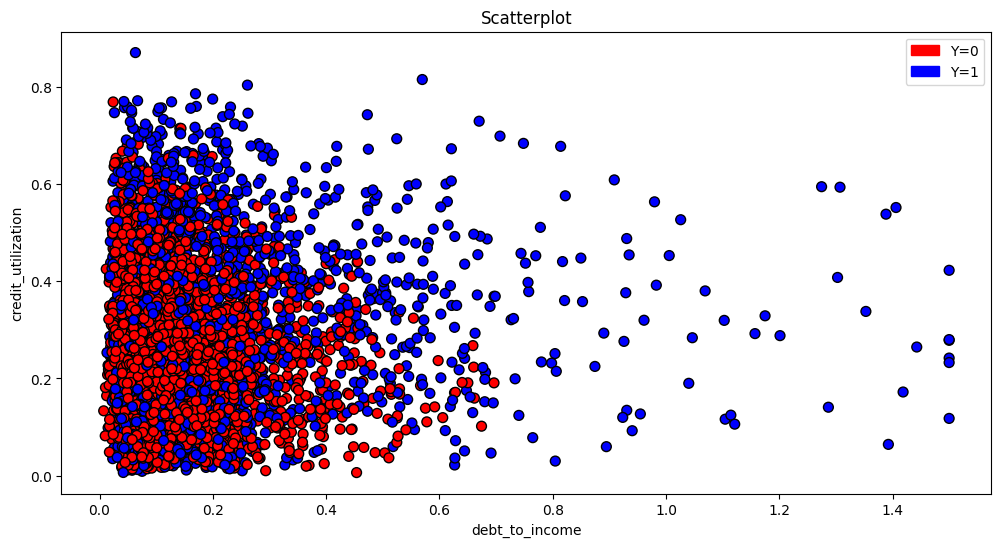

In [77]:
#Aufgabe_3_5
import numpy as np
X = X_train[["debt_to_income", "credit_utilization"]].values
y = y_train.values.ravel()

logisticRegr = LogisticRegression(l1_ratio=0, solver = 'liblinear')
model_3_5_1 = logisticRegr.fit(X, y)
y_score = model_3_5_1.predict(X)
#Score function from scikit:
print('Error rate:', np.mean(np.not_equal(model_3_5_1.predict(X),y)))

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
plot_symbol_size = 50
cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])
plt.figure(figsize=(12,6))
plt.scatter(X[:, 0], X[:, 1], s=plot_symbol_size, c=y, cmap=cmap_bold, edgecolor = 'black')
plt.xlabel("debt_to_income")
plt.ylabel("credit_utilization")
plt.title("Scatterplot")
patch0 = mpatches.Patch(color='#FF0000', label='Y=0')
patch1 = mpatches.Patch(color='#0000FF', label='Y=1')
plt.legend(handles=[patch0, patch1])
plt.show()

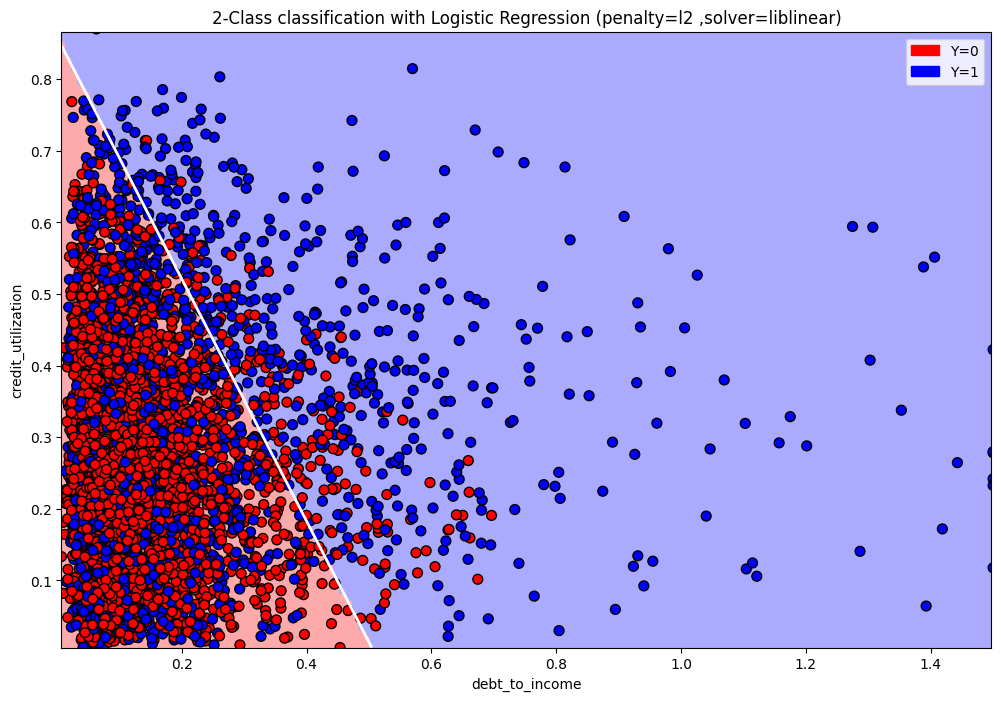

In [78]:
Y = y
pen = 'l2'
solv = 'liblinear'
# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])

# Plot the decision boundary by assigning a color in the color map to each mesh point.
mesh_step_size = .01  # step size in the mesh
plot_symbol_size = 50
    
x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
Z = model_3_5_1.predict(np.c_[xx.ravel(), yy.ravel()])
D = model_3_5_1.decision_function(np.c_[xx.ravel(), yy.ravel()])
D = D.reshape(xx.shape)

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(3,figsize=(12,8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot training points
plt.scatter(X[:, 0], X[:, 1], s=plot_symbol_size, c=Y, cmap=cmap_bold, edgecolor = 'black')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

patch0 = mpatches.Patch(color='#FF0000', label='Y=0')
patch1 = mpatches.Patch(color='#0000FF', label='Y=1')
plt.legend(handles=[patch0, patch1])
plt.contour(xx, yy, D, levels=[0], colors='w', linestyles=['-'], linewidths=2)
plt.xlabel('debt_to_income')
plt.ylabel('credit_utilization')
plt.title("2-Class classification with Logistic Regression (penalty=%s ,solver=%s)" % (pen, solv))    
plt.show()

Error rate: 0.2748


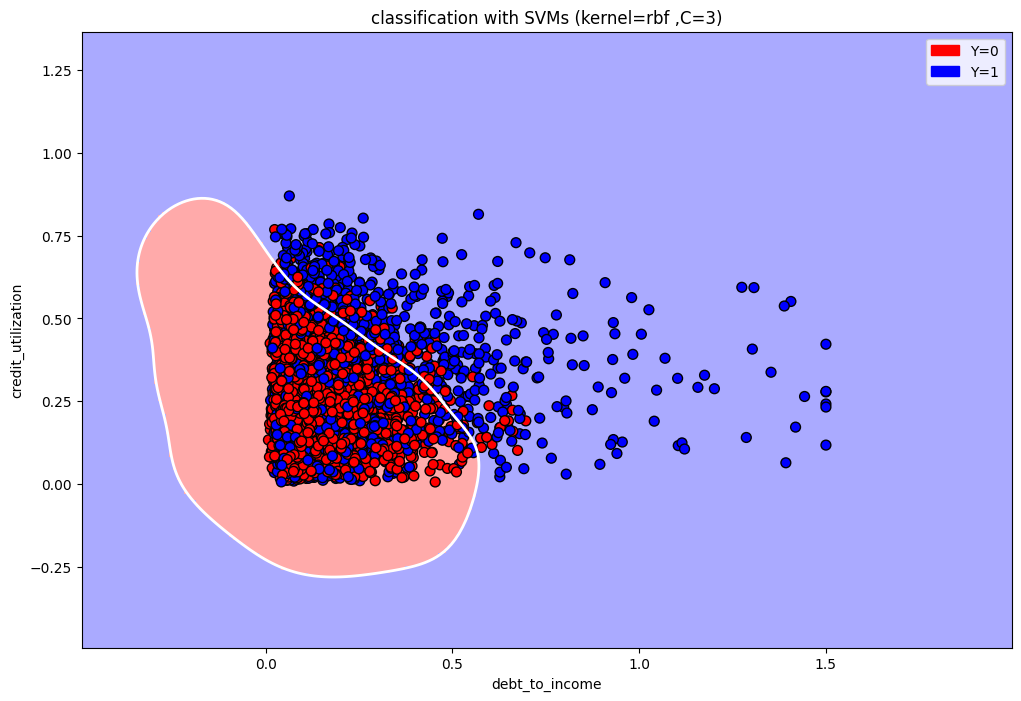

In [79]:
from sklearn import svm
supvecma = svm.SVC(kernel = 'rbf', C = 3)
model_3_5_2 = supvecma.fit(X, Y)
print('Error rate:', np.mean(np.not_equal(model_3_5_2.predict(X),y)))
#import matplotlib.cm as cm
from matplotlib.colors import ListedColormap#, BoundaryNorm
import matplotlib.patches as mpatches
Y = y
# Create color maps
cmap_light2 = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold2  = ListedColormap(['#FF0000', '#0000FF'])

# Plot the decision boundary by assigning a color in the color map to each mesh point.
mesh_step_size = .01  # step size in the mesh
plot_symbol_size = 50
    
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, y = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
Z = model_3_5_2.predict(np.c_[xx.ravel(), y.ravel()])
D = model_3_5_2.decision_function(np.c_[xx.ravel(), y.ravel()])
D = D.reshape(xx.shape)
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(3,figsize=(12,8))
plt.pcolormesh(xx, y, Z, cmap=cmap_light2)


# Plot training points
plt.scatter(X[:, 0], X[:, 1], s=plot_symbol_size, c=Y, cmap=cmap_bold2, edgecolor = 'black')
plt.xlim(xx.min(), xx.max())
plt.ylim(y.min(), y.max())

patch0 = mpatches.Patch(color='#FF0000', label='Y=0')
patch1 = mpatches.Patch(color='#0000FF', label='Y=1')
plt.legend(handles=[patch0, patch1])
plt.contour(xx, y, D, levels=[0], colors='w', linestyles=['-'], linewidths=2)
plt.xlabel('debt_to_income')
plt.ylabel('credit_utilization')
plt.title("classification with SVMs (kernel=rbf ,C=3)" )    
plt.show()

In [80]:
#Aufgabe 3_6

import numpy as np
from sklearn.ensemble import RandomForestClassifier
randforest = RandomForestClassifier(max_depth=5, random_state=0)
model_3_6 = randforest.fit(X_train, y_train.values.ravel())
print("Error rate:", np.mean(model_3_6.predict(X_train) != y_train.values.ravel()))
importance=pd.DataFrame([model_3_6.feature_importances_],index=["importance"], columns=X_train.columns).T.sort_values(by="importance", ascending=False)
importance.head()



Error rate: 0.2366


,importance
credit_utilization,0.240613
debt_to_income,0.237807
previous_defaults,0.109675
annual_income,0.088058
payment_history_score,0.067746


Yes, the first three values match, though they occur in a different order. 

In [ ]:
#Aufgabe 2_7_a
#import statsmodels.api as sm
#import sklearn.linear_model
X = X_train.values
y = y_train.values.ravel()

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
#X = regressor.values
#y = outcome.values
kf = KFold(n_splits=5, shuffle=True, random_state=12883823)
acc_log_reg_3_7 = []
acc_knn_3_7 = []
acc_svm_3_7 = []
acc_rf_3_7 = []
for train, test in kf.split(X):
    X_train_3_7, X_test_3_7, y_train_3_7, y_test_3_7 = X[train], X[test], y[train], y[test]

    # logistic regression
    y_pred_3_7_4 = model_3_7_1.predict(X_test_3_7)
    acc_log_reg_3_7.append(accuracy_score(y_test_3_7, y_pred_3_7_1))
    #print("Error rate:", np.mean(model_3_6.predict(X_train_3_7) != y_train_3_7.values.ravel()))

    # KNN
    y_pred_3_7_2 = model_3_7_2.predict(X_test_3_7)
    acc_knn_3_7.append(accuracy_score(y_test_3_7, y_pred_3_7_2))
    
    # SVM
    #svm_rbf = SVC(kernel='rbf', C=1)
    #svm_rbf.fit(X_train_k, y_train_k)
    #acc_rbf = svm_rbf.score(X_val_k, y_val_k)
    #rbf_results[1] = acc_rbf
    y_pred_3_7_3 = model_3_7_3.predict(X_test_3_7)
    acc_svm_3_7.append(accuracy_score(y_test_3_7, y_pred_3_7_3))
    
    #random forest
    model_3_7_4 = RandomForestClassifier(max_depth=5, random_state=0).fit(X_train_3_7, y_train_3_7)
    y_pred_3_7_4 = model_3_7_4.predict(X_test_3_7)
    acc_rf_3_7.append(accuracy_score(y_test_3_7, y_pred_3_7_4))


print(f"Average Accuracy Logistic Regression: {np.mean(acc_log_reg_3_7):.2%}")
print(f"Average Accuracy KNN: {np.mean(acc_knn_3_7):.2%}")
print(f"Average Accuracy SVM: {np.mean(acc_svm_3_7):.2%}")
print(f"Average Accuracy Random Forest: {np.mean(acc_rf_3_7):.2%}")

Average Accuracy Logistic Regression: nan%
Average Accuracy KNN: nan%
Average Accuracy SVM: nan%
Average Accuracy Random Forest: 73.70%


c:\Users\esoll\Desktop\Master\StatProg\Examiantion\Examination-WS25-26\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\esoll\Desktop\Master\StatProg\Examiantion\Examination-WS25-26\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


#Aufgabe_3_7_b
Eine Bewertung anhand der Accuracy kann problematisch sein, da die zugrundeliegende vorhergesehene Wahrscheinlichkeit nicht berücksichtigt wird. 

In [82]:
#Aufgabe 3_8
X_test_3_8 = pd.read_csv("../Daten//X_test.csv", index_col=0)
print(X_test_3_8)
#randforest wurde bereits in Aufgabe 3_6 definiert.
y_test_pred = model_3_6.predict_proba(X_test_3_8)

#print(y_test_pred)
model_3_6.classes_
predictions= y_test_pred[:,1] # Wahrscheinlichkeiten für die Klasse 1 (default)
print(predictions)
pd.Series(predictions).to_csv("../Daten//predictions.csv", header=["probability"], index_label="id")

      annual_income   age  employment_years  debt_to_income  credit_score  \
5000       61147.74  31.0               5.6          0.1838         643.0   
5001       52349.60  23.0               3.2          0.1138         708.0   
5002       33045.87  53.0               5.2          0.1785         634.0   
5003      108675.59  45.0               2.8          0.0517         642.0   
5004       32740.92  40.0               1.8          0.1445         727.0   
...             ...   ...               ...             ...           ...   
7495       25029.34  36.0               2.0          0.1550         657.0   
7496       50085.90  60.0               5.2          0.0828         745.0   
7497       56853.36  57.0              10.8          0.0940         760.0   
7498       41850.21  65.0               6.1          0.0846         702.0   
7499       75377.50  31.0               4.3          0.1191         682.0   

      credit_utilization  num_open_accounts  num_credit_inquiries  \
5000  